# Open Source Week

- Describe huggingface platform.
- Look at models datasets and spaces
- use google colab to code on GPU runtime

### HuggingFace Platform
- ubiquitous for llm engineering
- HuggingFace.co
    - Models: >800,000 open source models, variety of specialization.
    - Datasets: > 200,000 data sets
    - Spaces: Apps, expsed on huggingface cloud and available for public use. Leaderboards - Gradio apps that evaluate llms.

### HuggingFace Libraries
- HugginFace Hub: login, upload and download datasets
- Datasets library: access to repositories
- transformers: wrapper code around llm transformer architectures. Deep neural Network code.

- peft: parameter efficient fine tuning. Training LLMs without working with billions of parameters. use LORA.
- trl: Transformer Reinforcement Learning, reward modelling (rm), proximal policy optimization (ppo), supervised fine tuning (sft).
- accelerate: advanced code for running transformers across efficiently across multiple GPUs.


# Google Colab

- Run Jupyter lab in the cloud and with a powerful GPU.
- Share notebooks like google docs etc.
- Runtimes:
    - CPU based
    - Lower spec GPU for low cost
    - High spec GPU runtime for intensive runs

# HuggingFace Open-source Coding

HugginFace transformers have 2 different API levels:

- Pipelines: high-level, carries out standard tasks quickly
- Tokenizers & Models: Low level, most power and control

### Pipelines

Instant advantage of open source models on Huggingface
Classic examples:
    Sentiment analysis
    Classification
    Named entity recognition
    Question and Answering
    Summarization
    Translation

More advanced:
    Text Generation
    Image generation
    Audio generation



# HuggingFace pipelines

For this session we head to Google Colab and use this Notebook to explore the HuggingFace High Level API, pipelines.

https://colab.research.google.com/drive/1aMaEw8A56xs0bRM4lu8z7ou18jqyybGm?usp=sharing

You can use a low cost (or free) T4 GPU runtime for this notebook - and the results look great!

There are instructions in the notebook for setting up your HuggingFace Token and including it as a secret in the notebook.

# Day 3
## Tokenizers

- Trannslates between Text and Tokens with encode() and decode()
- Contains a Vocab that can include special tokens to signal information, like 'Start Conversation', 'End of sentence', etc..
- Can include 'Chat template' that tells it how to format messages

Different llms often have different Tokenizers

Meta paved the way for opensource models with Llama3.1

Others:
- Phi3: Microsoft
- Qwen2 - Alibaba Cloud
- Starcoder2

# Tokenizers

Please can I bring you back to the wonderful Google Colab where we'll look at different Tokenizers:

https://colab.research.google.com/drive/1WD6Y2N7ctQi1X9wa6rpkg8UfyA4iSVuz?usp=sharing

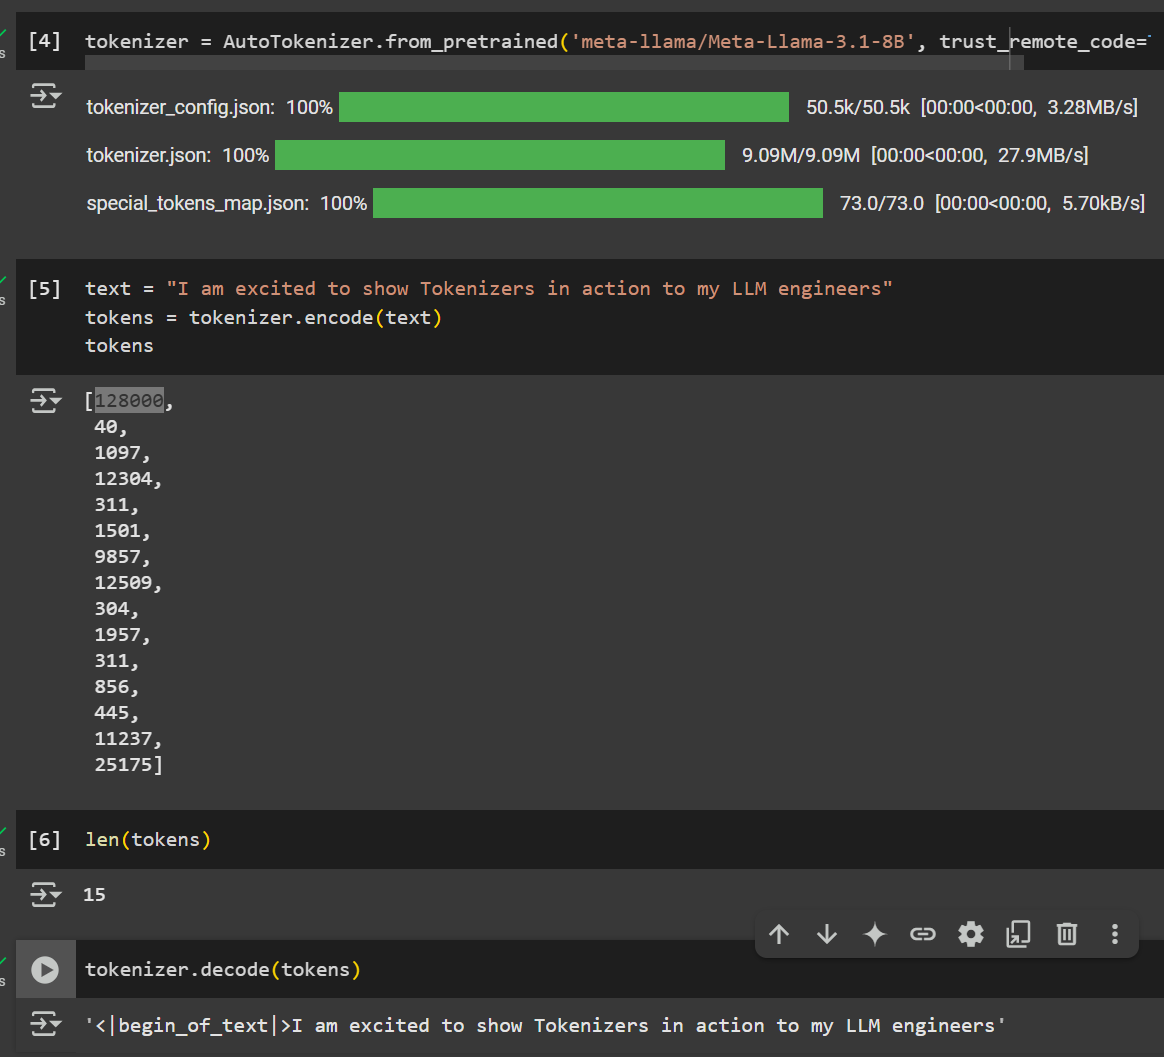

Tokens in the training data teach the model when to reply, basically how to "converse"

Phi 3 - Seemingly no special tokens returned by the model batch decode

# Models

- create a transformer and run to generate text
- comparing across 5 models
- Llama3.1, Phi3, Gemma, Mixtral, Qwen2

Covering 3 aspects:

Quantization - Reducing precision of weights in model to reduce memory usage/size

Model internals - What do the PyTorch layers look like behind the huggingface API

Streaming - Stream results from opensource models



# Models

And now - this colab unveils the heart (or the brains?) of the transformers library - the models:

https://colab.research.google.com/drive/1hhR9Z-yiqjUe7pJjVQw4c74z_V3VchLy?usp=sharing

This should run nicely on a low-cost or free T4 box.

## Quantization

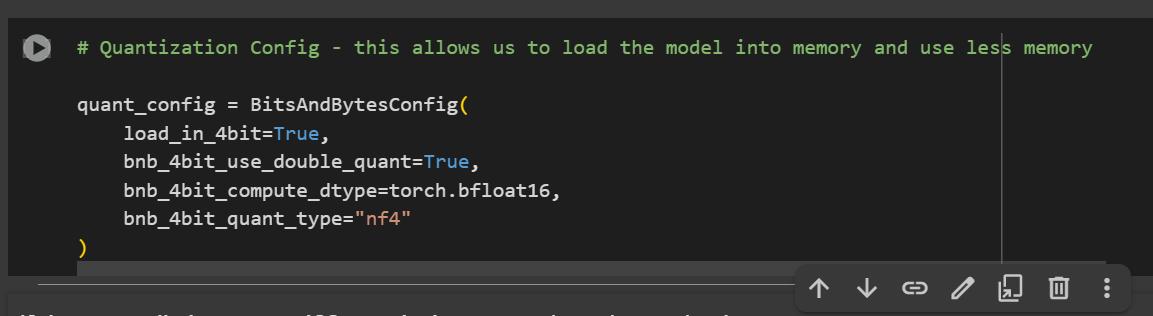

Quantization - 
Load in a model into memory, but reduce precision of numbers. 
Usually 32-bit number weights, quantization lets us bring them in as low as 4-bit numbers



This reduces the accuracy of the model, but not linearly - tradeoff is worth it in many cases

In [ ]:
Generate from model

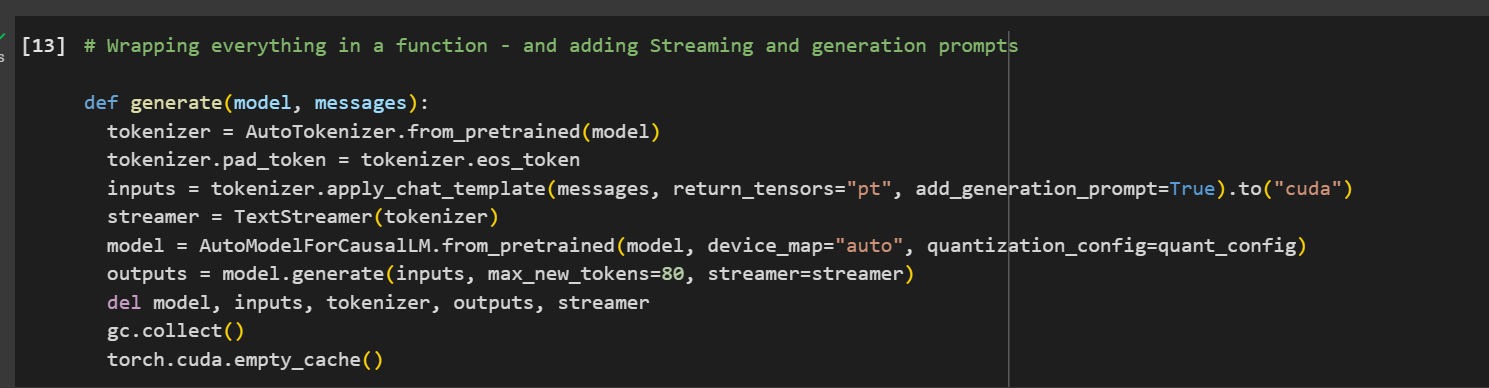

In [ ]:
AutoTokenizer.from_pretrained(model) // gets the model from huggingface library
tokenizer.pad_token = tokenizer.eos_token // boilerplate, pads end of sentance if necessary

inputs = tokenizer.apply_chat_template(...) applies the models special tokens to message. 'adde_generation_prompt' tells the model to respond to the message, not continue it.
streamer = TextStreamer() // gets the streaming output from huggingface

model = AutoModelForCausalLM.from_pretrained(model, device_map="auto", quantization_config)
// downloads the model from huggingface, device_map "auto" tells it to run it on the gpu if we have one, quantization as before.

del model, inputs etc. // clean up memory since its large
gc.collect
torch.cud.empty cache

# WEEK 3 Challenge

Create an application that takes minutes from an audio file and streams to gradio UI using a opensource model and frontier model.

# My solution:

In [ ]:
# imports

import os
import requests
import gradio
from IPython.display import Markdown, display, update_display
from openai import OpenAI
from google.colab import drive
from huggingface_hub import login
from google.colab import userdata
from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer, BitsAndBytesConfig
import torch

In [ ]:
# consts

AUDIO_MODEL = 'whisper-1'
LLAMA = "meta-llama/Meta-Llama-3.1-8B-Instruct"

system_message = "You are an assistant that produces minutes of meetings from transcripts, with summary, key discussion points, takeaways and action items with owners, in markdown."
user_prompt = f"Below is an extract transcript of a Denver council meeting. Please write minutes in markdown, including a summary with attendees, location and date; discussion points; takeaways; and action items with owners.\n"

messages = [
    {"role":"system", "content":user_prompt},
    {"role":"user", "content":""}
]

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

In [ ]:
# Generate text from audio

def get_audio_file(file_name):
  #drive.mount("/content/drive")
  audio_file = open(file_name, 'rb', )
  return audio_file


def generate_transcript(audio) -> str:
  transcription = openai.audio.transcriptions.create(model=AUDIO_MODEL, file=audio_file, response_format="text")
  return transcription


In [ ]:
# Stream formatted minutes from text

def generate_markdown_response(from_text: str):
  internal_user_message = user_prompt + from_text

  internal_messages = messages.copy()
  internal_messages[1]["content"] = internal_user_message
  
  tokenizer = AutoTokenizer.from_pretrained(LLAMA)
  tokenizer.pad_token = tokenizer.eos_token
  
  inputs = tokenizer.apply_chat_template(messages, return_tensors="pt").to("cuda")

  streamer = TextStreamer(tokenizer)

  model = AutoModelForCausalLM.from_pretrained(LLAMA, device_map="auto", quantization_config=quant_config)
  
  outputs = model.generate(inputs, max_new_tokens=2000, streamer=streamer)
  output_text = tokenizer.decode(outputs[0])
  return output_text


In [ ]:
# Everything together, called by gradio ui

def transcribe(file_path: str) -> str:
  audio_file = get_audio_file(file_path)
  transcript = generate_transcript(audio_file)
  response = generate_markdown_response(transcript)
  return response

In [ ]:
# Gradio ui

def launch(inbrowser=True):
  with gradio.Blocks() as ui:

    with gradio.Row():
      output = gradio.Markdown("See your minutes here in seconds! Just enter the file path below and we can get started")

    with gradio.Row():
      entry = gradio.Textbox(label="enter file path.")
      submit = gradio.Button("Submit")

    entry.submit(transcribe, inputs=[entry], outputs=[output])
    
  ui.launch(inbrowser=inbrowser, debug=True)

In [ ]:
launch()

# WEEK 3 EXERCISE

In [ ]:
Create a tool that generates synthetic test data.

- Describe a kind of dataset you want.
- Tell it what kind of data and 'dream up' diverse outputs
- gradio ui

In [ ]:
# login server history generator
# Generates list such as:

# {"date-time-string": "time_here", 
# "player_id": "player_id_here", 
# "username": "username_here", 
# "server_id": "server_id_here", 
# "server_name", "server_name_here", 
# "time_since_last_login":"last_login_time_herer"}

### NOTE: Requires GoogleColab for function

In [ ]:
# imports

import os
import requests
import gradio
from IPython.display import Markdown, display, update_display
from openai import OpenAI
from google.colab import drive
from huggingface_hub import login
from google.colab import userdata
from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer, BitsAndBytesConfig
import torch

In [ ]:
# consts

LLAMA = "meta-llama/Meta-Llama-3.1-8B-Instruct"


system_message = "You are an assistant that generates test data for database testing. The database is for customer information, including their msot recent purchases from a supermarket. \n"
system_message += "You are to generate 10 samples for testing in the following form:\n"
system_message += """{name: CustomerName, DOB: 1975-04-21, purchase: {item1: 10, item2: 25.53, item3: 15.99}, total_price: 51.52}"""
system_message += "\n it is important that the data is in exactly the dictionary format above in order to test the database."

system_prompt = [
    {"role": "system", "content": system_message},
    {"role":"user", "content": "Please generate 10 customers for database testing"}
]


quantize_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

In [ ]:
# Running the model

tokenizer = AutoTokenizer.from_pretrained(LLAMA)
tokenizer.pad_token = tokenizer.eos_token
inputs = tokenizer.apply_chat_template(system_prompt, return_tensors="pt").to("cuda")
stream = TextStreamer(tokenizer)
model = AutoModelForCausalLM.from_pretrained(LLAMA, device_map="auto", quantization_config=quantize_config)
outputs = model.generate(inputs, max_new_tokens=2000, streamer=streamer)